# Model Comparison
Loads metrics from `models/rf/` and `models/gbm/` and compares all four models.
Also writes a combined `models/metrics.joblib` so the dashboard reflects all results.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from config import RF_MODELS_DIR, GBM_MODELS_DIR, MODELS_DIR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
rf_met  = joblib.load(RF_MODELS_DIR  / 'metrics.joblib')
gbm_met = joblib.load(GBM_MODELS_DIR / 'metrics.joblib')

# Merge all four model metrics into one dict
all_metricas = {**rf_met['metricas'], **gbm_met['metricas']}
all_roc      = {**rf_met['roc_curves'], **gbm_met['roc_curves']}
all_pr       = {**rf_met['pr_curves'],  **gbm_met['pr_curves']}
pos_rate     = rf_met['pos_rate']

df_metrics = (
    pd.DataFrame(all_metricas).T
    .rename(columns={'roc': 'ROC-AUC', 'pr': 'PR-AUC'})
    .sort_values('ROC-AUC', ascending=False)
)
print('=== All models — honest evaluation on same hold-out ===')
print(df_metrics.to_string())

=== All models — honest evaluation on same hold-out ===
                ROC-AUC  PR-AUC
GBM Global       0.5845  0.2157
RF Global        0.5761  0.2116
RF Segmentado    0.5429  0.1805
GBM Segmentado   0.5140  0.1721


## ROC-AUC and PR-AUC comparison

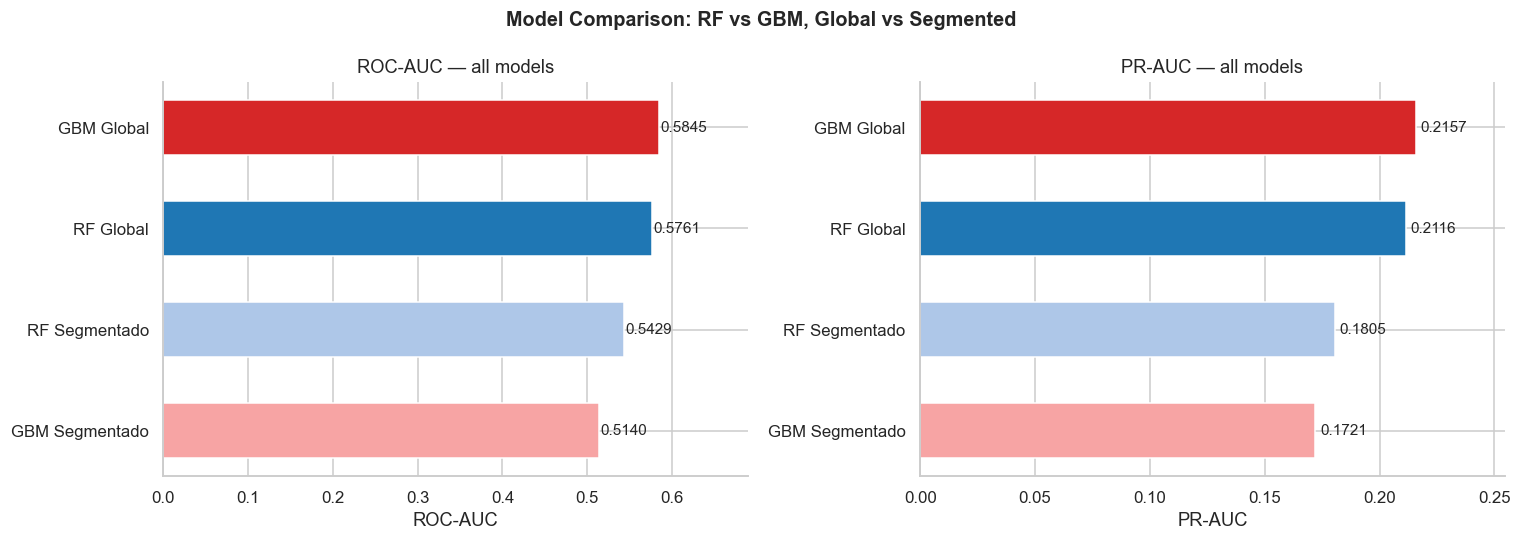

In [3]:
colors = {'RF Global': '#1f77b4', 'RF Segmentado': '#aec7e8',
          'GBM Global': '#d62728', 'GBM Segmentado': '#f7a4a4'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax in zip(['ROC-AUC', 'PR-AUC'], axes):
    vals = df_metrics[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values,
                   color=[colors.get(k, '#888') for k in vals.index],
                   edgecolor='white', height=0.55)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=10)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — all models')
    ax.set_xlim(0, vals.max() * 1.18)

plt.suptitle('Model Comparison: RF vs GBM, Global vs Segmented', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ROC curves

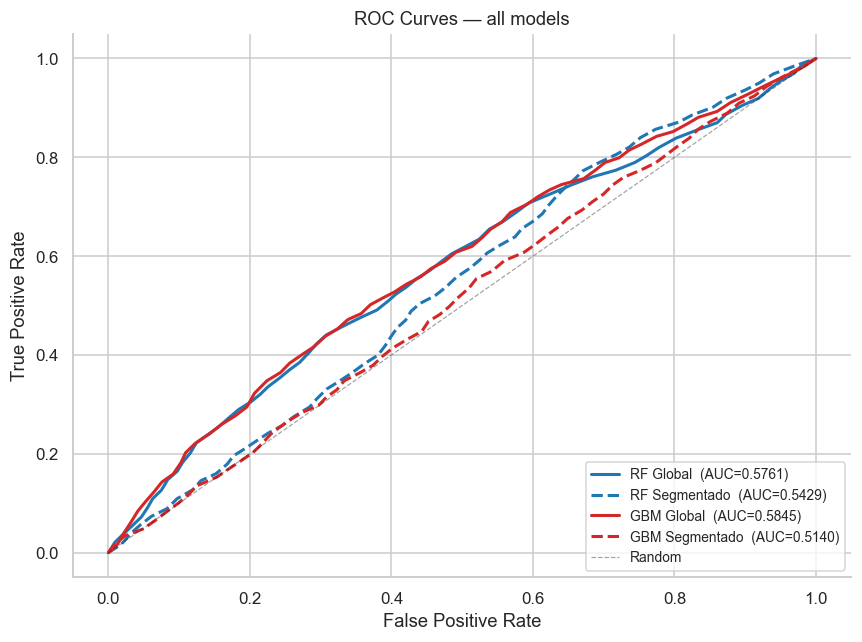

In [4]:
styles = {'RF Global': ('-', '#1f77b4'), 'RF Segmentado': ('--', '#1f77b4'),
          'GBM Global': ('-', '#d62728'), 'GBM Segmentado': ('--', '#d62728')}

fig, ax = plt.subplots(figsize=(8, 6))
for label, (fpr, tpr) in all_roc.items():
    ls, col = styles.get(label, ('-', '#888'))
    auc = all_metricas[label]['roc']
    ax.plot(fpr, tpr, linestyle=ls, color=col, linewidth=2,
            label=f'{label}  (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — all models')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Per-segment ROC-AUC (segmented models)

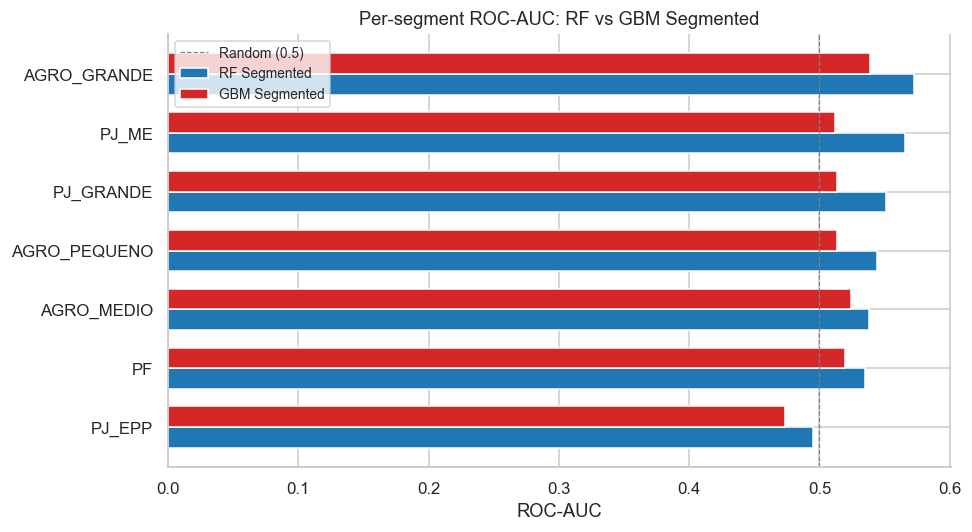

              RF Seg  GBM Seg winner
PJ_EPP        0.4950   0.4732     RF
PF            0.5350   0.5199     RF
AGRO_MEDIO    0.5383   0.5242     RF
AGRO_PEQUENO  0.5445   0.5131     RF
PJ_GRANDE     0.5511   0.5131     RF
PJ_ME         0.5658   0.5119     RF
AGRO_GRANDE   0.5723   0.5391     RF


In [5]:
rf_seg  = pd.Series({k: v['roc'] for k, v in rf_met['seg_metricas'].items()},  name='RF Seg')
gbm_seg = pd.Series({k: v['roc'] for k, v in gbm_met['seg_metricas'].items()}, name='GBM Seg')
seg_df  = pd.concat([rf_seg, gbm_seg], axis=1).sort_values('RF Seg', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(seg_df))
w = 0.35
ax.barh(x - w/2, seg_df['RF Seg'],  w, color='#1f77b4', label='RF Segmented',  edgecolor='white')
ax.barh(x + w/2, seg_df['GBM Seg'], w, color='#d62728', label='GBM Segmented', edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(seg_df.index)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random (0.5)')
ax.set_xlabel('ROC-AUC')
ax.set_title('Per-segment ROC-AUC: RF vs GBM Segmented')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(seg_df.assign(winner=seg_df.apply(lambda r: 'RF' if r['RF Seg'] > r['GBM Seg'] else 'GBM', axis=1)).to_string())

## Summary and winner

In [6]:
best_global = df_metrics.loc[df_metrics.index.str.endswith('Global'), 'ROC-AUC'].idxmax()
best_seg    = df_metrics.loc[df_metrics.index.str.endswith('Segmentado'), 'ROC-AUC'].idxmax()
best_overall = df_metrics['ROC-AUC'].idxmax()

print('=== Summary ===')
print(f'Best global model   : {best_global}  (ROC={df_metrics.loc[best_global, "ROC-AUC"]:.4f})')
print(f'Best segmented model: {best_seg}  (ROC={df_metrics.loc[best_seg, "ROC-AUC"]:.4f})')
print(f'Best overall        : {best_overall}  (ROC={df_metrics.loc[best_overall, "ROC-AUC"]:.4f})')
print()
print('Global always beats segmented — adding segment/sector as features to a single model')
print('works better than training isolated submodels on the small per-group samples.')

=== Summary ===
Best global model   : GBM Global  (ROC=0.5845)
Best segmented model: RF Segmentado  (ROC=0.5429)
Best overall        : GBM Global  (ROC=0.5845)

Global always beats segmented — adding segment/sector as features to a single model
works better than training isolated submodels on the small per-group samples.


## Write combined metrics.joblib for the dashboard

In [7]:
# Best segmented metrics for per-segment breakdown in dashboard
best_seg_metricas = (
    rf_met['seg_metricas'] if rf_met['metricas']['RF Segmentado']['roc']
    >= gbm_met['metricas']['GBM Segmentado']['roc']
    else gbm_met['seg_metricas']
)

combined = {
    'metricas':     all_metricas,
    'seg_metricas': best_seg_metricas,
    'roc_curves':   all_roc,
    'pr_curves':    all_pr,
    'pos_rate':     pos_rate,
}
joblib.dump(combined, MODELS_DIR / 'metrics.joblib')
print(f'Written → {MODELS_DIR / "metrics.joblib"}')
print('Dashboard will now show all four models in the metrics tab.')

Written → /home/paolot/Workspace/BB_data_analysis/models/metrics.joblib
Dashboard will now show all four models in the metrics tab.
